# Gradient Boosting Regression

Ноутбук:
- Чем Gradient Boosting отличается от одной модели Decision Tree
- Как деревья учатся последовательно, исправляя ошибки предыдущих
- Влияние `n_estimators` (количество деревьев), `learning_rate` (шаг обучения), `max_depth` (глубины)
- Метрики: MSE, RMSE, MAE, R²
- Сравнение с LinearRegression и DecisionTreeRegressor

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

def make_booster(**kw):
    return LGBMRegressor(verbose=-1, **kw)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Данные

Используем синтетический датасет `make_friedman1` — нелинейная задача регрессии с 10 признаками (суть в том, что только 5 из них реально полезны).

In [ ]:
X, y = make_friedman1(n_samples=2000, n_features=10, noise=1.0, random_state=42)
feature_names = [f'f{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)
X.head()

Train: (1500, 10) | Test: (500, 10)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,0.708073
1,0.020584,0.969910,0.832443,0.212339,0.181825,0.183405,0.304242,0.524756,0.431945,0.291229
2,0.611853,0.139494,0.292145,0.366362,0.456070,0.785176,0.199674,0.514234,0.592415,0.046450
3,0.607545,0.170524,0.065052,0.948886,0.965632,0.808397,0.304614,0.097672,0.684233,0.440152
4,0.122038,0.495177,0.034389,0.909320,0.258780,0.662522,0.311711,0.520068,0.546710,0.184854


## 2. Один Decision Tree и Gradient Boosting

**Идея:**
- *Один Decision Tree* — пытается описать всё одной структурой. Глубокое — переобучается, мелкое — недообучается.
- *Gradient Boosting* — строит **много слабых** (мелких) деревьев **последовательно**. Каждое новое дерево учится на **остатках** (ошибках) предыдущей модели и понемногу улучшает её.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


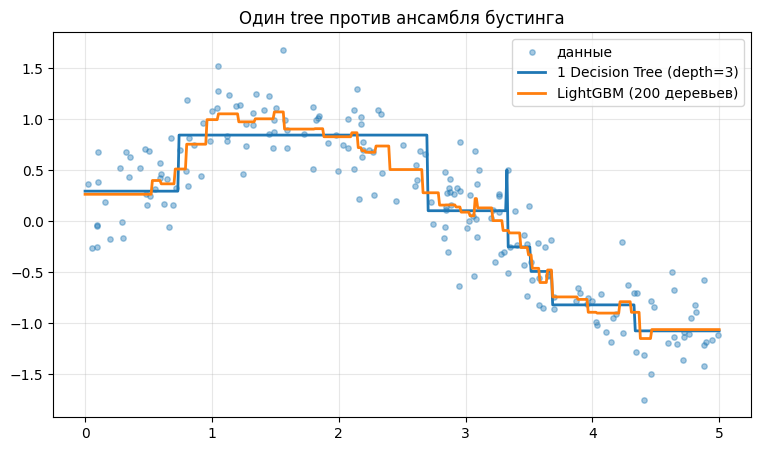

In [ ]:
rng = np.random.RandomState(0)
X1 = np.sort(5 * rng.rand(200, 1), axis=0)
y1 = np.sin(X1).ravel() + 0.3 * rng.randn(200)

tree = DecisionTreeRegressor(max_depth=3).fit(X1, y1)
gb = make_booster(n_estimators=200, learning_rate=0.1, max_depth=3).fit(X1, y1)

X_grid = np.linspace(0, 5, 500).reshape(-1, 1)

plt.scatter(X1, y1, s=15, alpha=0.4, label='данные')
plt.plot(X_grid, tree.predict(X_grid), label='1 Decision Tree (depth=3)', lw=2)
plt.plot(X_grid, gb.predict(X_grid), label=f'LightGBM (200 деревьев)', lw=2)
plt.title('Один tree против ансамбля бустинга')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Видно: одно дерево даёт «ступеньки», бустинг — гладкую и точную аппроксимацию.

## 3. Как деревья последовательно исправляют ошибки

Покажем «ручной» бустинг: каждое следующее дерево учится на **остатках** текущего предсказания.

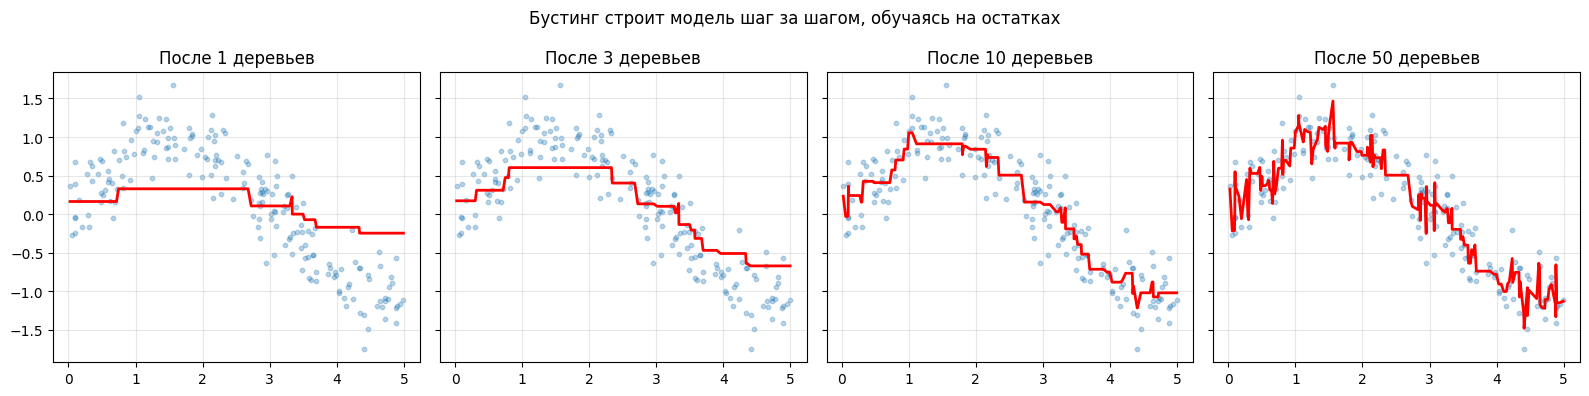

In [ ]:
lr = 0.3
pred = np.full_like(y1, fill_value=y1.mean(), dtype=float)
stages = [1, 3, 10, 50]
trees = []

fig, axes = plt.subplots(1, len(stages), figsize=(16, 4), sharey=True)
for i in range(max(stages) + 1):
    if i in stages:
        ax = axes[stages.index(i)]
        ax.scatter(X1, y1, s=10, alpha=0.3)
        order = np.argsort(X1.ravel())
        ax.plot(X1[order], pred[order], color='red', lw=2)
        ax.set_title(f'После {i} деревьев')
        ax.grid(alpha=0.3)
    residuals = y1 - pred
    t = DecisionTreeRegressor(max_depth=3).fit(X1, residuals)
    pred += lr * t.predict(X1)

plt.suptitle('Бустинг строит модель шаг за шагом, обучаясь на остатках')
plt.tight_layout(); plt.show()

С каждым новым деревом красная линия всё лучше повторяет форму данных.

## 4. Влияние гиперпараметров

- **`n_estimators`** — сколько деревьев. Больше = точнее, но возможен overfitting.
- **`learning_rate`** — насколько сильно учитывать каждое новое дерево. Меньше = устойчивее, но нужно больше деревьев.
- **`max_depth`** — глубина одного дерева. Большая = сильные деревья, но риск переобучения.

### Learning curve по числу деревьев

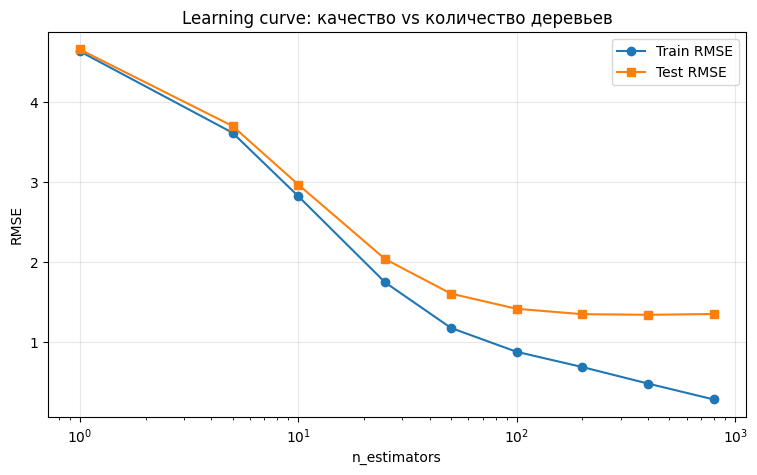

In [ ]:
n_list = [1, 5, 10, 25, 50, 100, 200, 400, 800]
train_rmse, test_rmse = [], []

for n in n_list:
    m = make_booster(n_estimators=n, learning_rate=0.1, max_depth=4).fit(X_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

plt.plot(n_list, train_rmse, marker='o', label='Train RMSE')
plt.plot(n_list, test_rmse, marker='s', label='Test RMSE')
plt.xscale('log')
plt.xlabel('n_estimators'); plt.ylabel('RMSE')
plt.title('Learning curve: качество vs количество деревьев')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Сравнение разных `learning_rate`

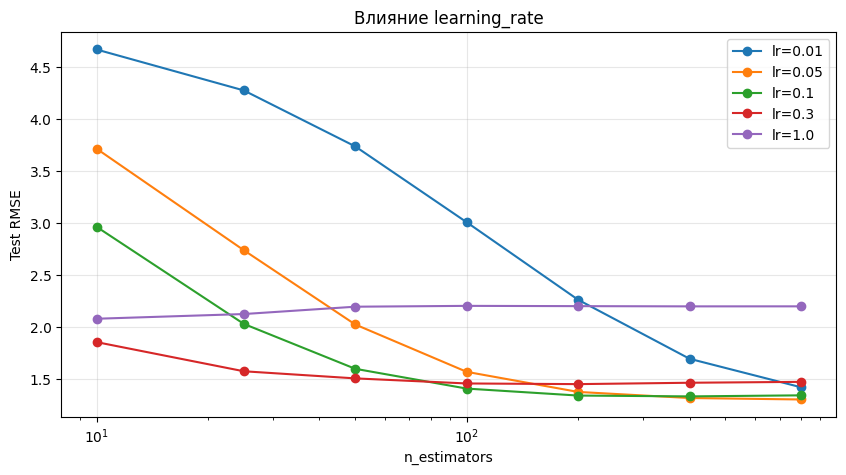

In [ ]:
lrs = [0.01, 0.05, 0.1, 0.3, 1.0]
n_grid = [10, 25, 50, 100, 200, 400, 800]

plt.figure(figsize=(10, 5))
for lr in lrs:
    rmses = []
    for n in n_grid:
        m = make_booster(n_estimators=n, learning_rate=lr, max_depth=4).fit(X_train, y_train)
        rmses.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))
    plt.plot(n_grid, rmses, marker='o', label=f'lr={lr}')

plt.xscale('log')
plt.xlabel('n_estimators'); plt.ylabel('Test RMSE')
plt.title('Влияние learning_rate')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Маленький `learning_rate` нужен в паре с большим количеством деревьев. Слишком большой `learning_rate` (например, 1.0) делает обучение нестабильным.

## 5. Финальная модель и метрики

In [ ]:
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'model': name,
        'MSE':  mse,
        'RMSE': np.sqrt(mse),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

lr_model = LinearRegression().fit(X_train, y_train)
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X_train, y_train)
gb_model = make_booster(n_estimators=400, learning_rate=0.05, max_depth=4).fit(X_train, y_train)

results = pd.DataFrame([
    evaluate('LinearRegression',     y_test, lr_model.predict(X_test)),
    evaluate('DecisionTreeRegressor', y_test, dt_model.predict(X_test)),
    evaluate(f'LightGBM',       y_test, gb_model.predict(X_test)),
]).set_index('model')
results.round(4)

,MSE,RMSE,MAE,R2
model,,,,
LinearRegression,6.1253,2.4749,1.9702,0.7519
DecisionTreeRegressor,7.2171,2.6865,2.1006,0.7076
LightGBM,1.7440,1.3206,1.0397,0.9293


### Предсказания и реальные значения

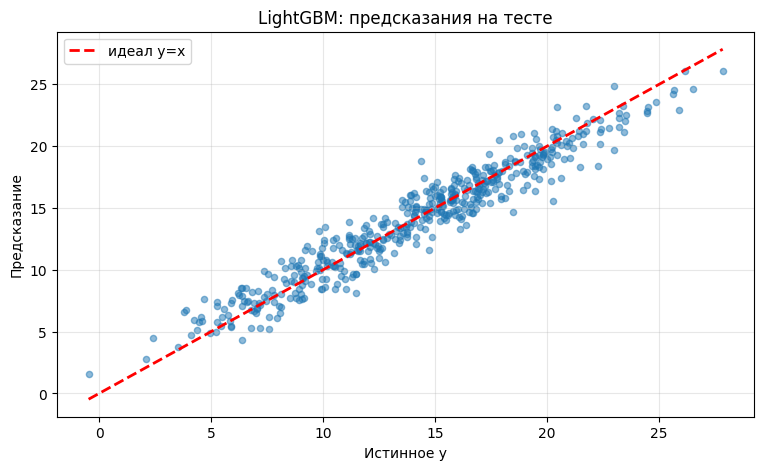

In [ ]:
y_pred = gb_model.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5, s=20)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=2, label='идеал y=x')
plt.xlabel('Истинное y'); plt.ylabel('Предсказание')
plt.title(f'LightGBM: предсказания на тесте')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Feature importance

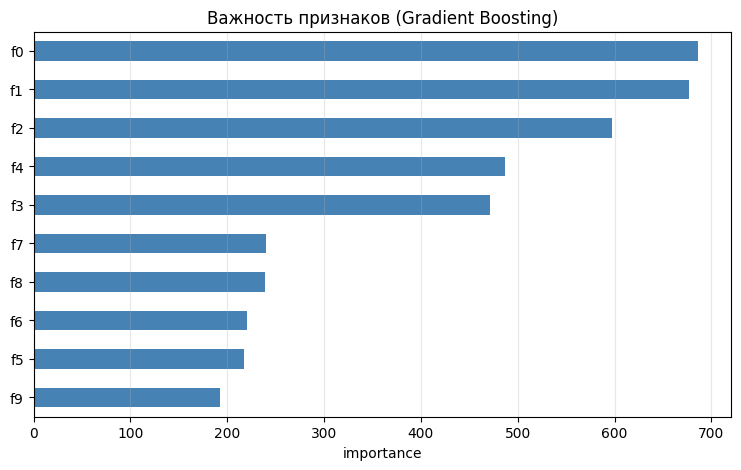

In [ ]:
imp = pd.Series(gb_model.feature_importances_, index=feature_names).sort_values()
imp.plot(kind='barh', color='steelblue')
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('importance'); plt.grid(alpha=0.3, axis='x'); plt.show()

В `make_friedman1` реально полезны только первые 5 признаков (`f0`–`f4`) — модель это правильно «нашла».

### Сравнение метрик на графике: bar chart

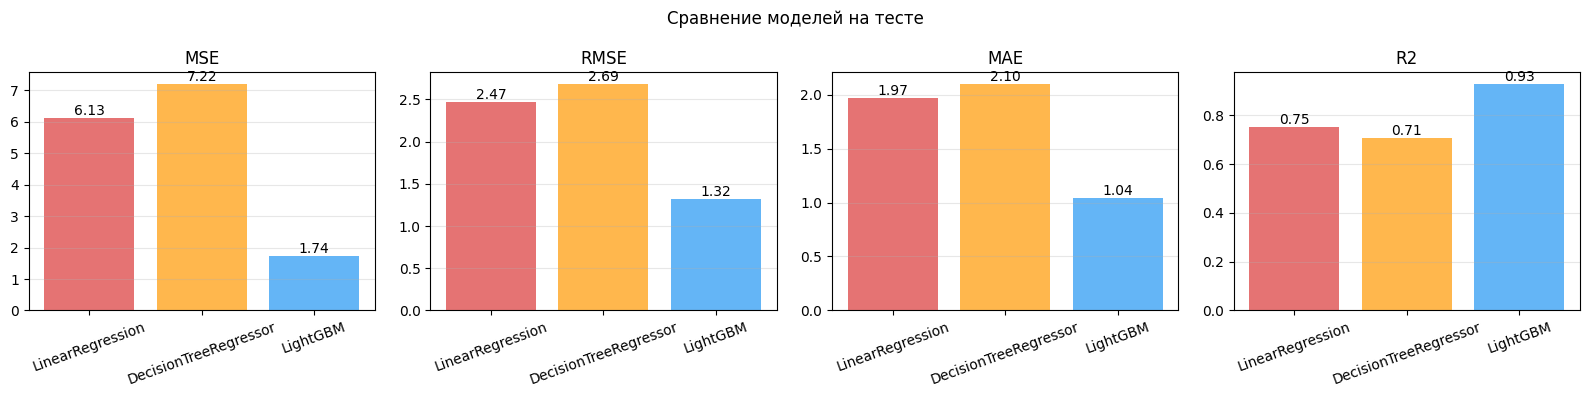

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
colors = ['#e57373', '#ffb74d', '#64b5f6']

for ax, metric in zip(axes, metrics):
    vals = results[metric]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(vals.values):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.suptitle('Сравнение моделей на тесте')
plt.tight_layout(); plt.show()

#**Общий итог:**

- **Один Decision Tree** даёт ступенчатые предсказания и легко переобучается / недообучается.
- **LinearRegression** не справляется с нелинейностями.
- **Gradient Boosting** строит много слабых деревьев последовательно, каждое — на остатках предыдущих. В итоге получает лучшие RMSE, MAE и R².
- Главные «крутилки»: `n_estimators` (сколько деревьев), `learning_rate` (шаг), `max_depth` (сложность одного дерева). Хорошее правило — маленький `learning_rate` + много деревьев.